In [17]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import pearsonr, spearmanr
import glob
import os


In [18]:
src_dir = '/storage/cdalden/goes/surface_obs/gucceilM1.b1/'
pattern = os.path.join(src_dir, '*.custom.nc')
files = sorted(glob.glob(pattern))
print(f'Found {len(files)} files')

# Concatenate by coordinates (assumes each file has consistent schema and time axis)
# If files have overlapping times, xarray will align by 'time'
ds_all = xr.open_mfdataset(
    files,
    combine='by_coords',
    parallel=True,
    engine='netcdf4'
)

# Optional: ensure time is sorted and unique
if 'time' in ds_all.coords:
    ds_all = ds_all.sortby('time')

out_path = os.path.join(src_dir, 'sail_guc_ceilometer_2021_2023.nc')
ds_all.to_netcdf(out_path)
print(f'Saved merged dataset to: {out_path}')

Found 276 files


/tmp/ipykernel_141616/3008524839.py:8: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_all = xr.open_mfdataset(
/tmp/ipykernel_141616/3008524839.py:8: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_all = xr.open_mfdataset(
/tmp/ipykernel_141616/3008524839.py:8: FutureWarning: In a future version of xarray th

Saved merged dataset to: /storage/cdalden/goes/surface_obs/gucceilM1.b1/sail_guc_ceilometer_2021_2023.nc


In [9]:
path = '/storage/cdalden/goes/surface_obs/gucceilM1.b1/'
file = 'sail_guc_ceilometer_2021_2023.nc'
ceil_ds = xr.open_dataset(path + file)

path_tsi = '/storage/cdalden/goes/surface_obs/sail_total_sky_imager/'
file_tsi = 'sail_tsi_cloud_frac.csv'
tsi_df = pd.read_csv(path_tsi + file_tsi)
# remove negative values
tsi_df = tsi_df[tsi_df['tsi_frac'] >= 0]
tsi_df['t'] = pd.to_datetime(tsi_df['t'])
tsi_df = tsi_df.set_index('t')
# resample to hourly
tsi_df = tsi_df.resample('1h').mean()

In [10]:
ceil_ds

<xarray.Dataset> Size: 56MB
Dimensions:                 (time: 664182, range: 252)
Coordinates:
  * time                    (time) datetime64[ns] 5MB 2022-05-01T00:00:12 ......
  * range                   (range) float32 1kB 15.0 45.0 ... 7.545e+03
Data variables: (12/17)
    base_time               (time) datetime64[ns] 5MB ...
    time_offset             (time) datetime64[ns] 5MB ...
    first_cbh               (time) float32 3MB ...
    qc_first_cbh            (time) int32 3MB ...
    qc_vertical_visibility  (time) int32 3MB ...
    qc_second_cbh           (time) int32 3MB ...
    ...                      ...
    qc_tilt_angle           (time) int32 3MB ...
    qc_background_light     (time) int32 3MB ...
    qc_sum_backscatter      (time) int32 3MB ...
    lat                     (time) float32 3MB ...
    lon                     (time) float32 3MB ...
    alt                     (time) float32 3MB ...

<Axes: xlabel='t'>

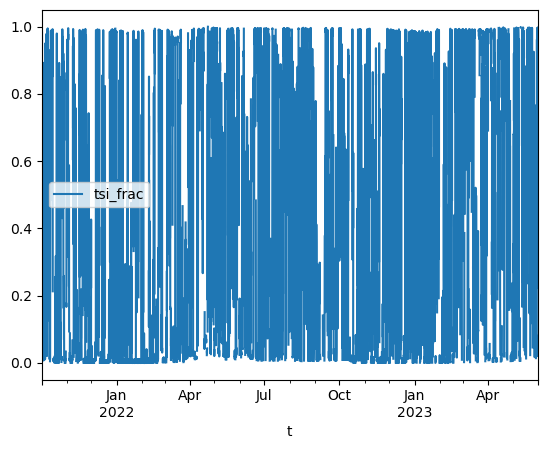

In [11]:
tsi_df.plot()

/tmp/ipykernel_141616/331694577.py:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_cloud_frac = cbh_df['cloud_binary'].resample('1H').mean()


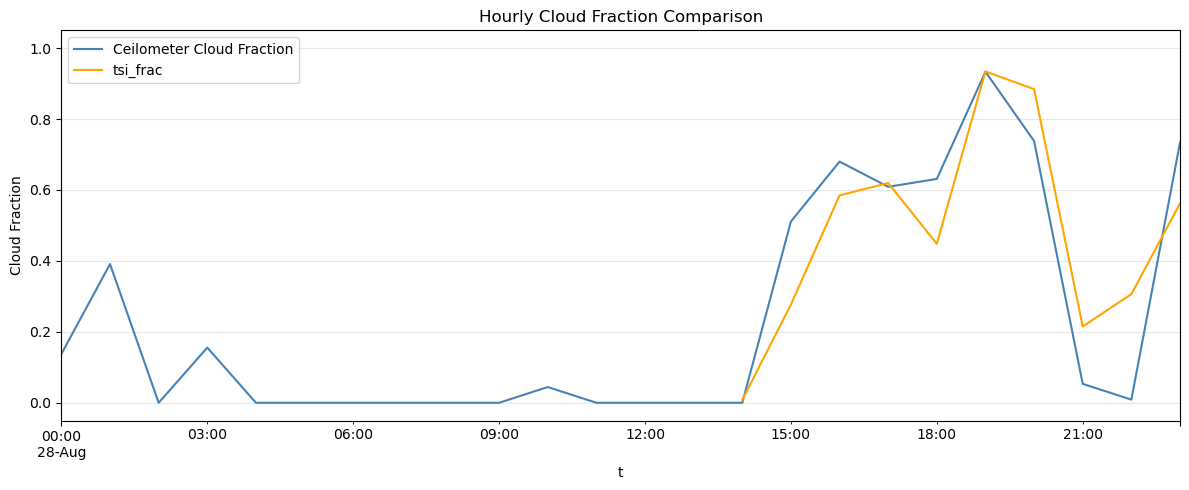

In [12]:
# Convert first_cbh to a dataframe and resample to hourly cloud fraction
cbh_df = ceil_ds.first_cbh.to_dataframe().reset_index()
cbh_df['time'] = pd.to_datetime(cbh_df['time'])
cbh_df = cbh_df.set_index('time')

# Create a binary cloud indicator (1 if CBH exists/has value, 0 if missing/no cloud)
cbh_df['cloud_binary'] = (~cbh_df['first_cbh'].isna()).astype(int)

# Resample to hourly and calculate fraction of timesteps with clouds
hourly_cloud_frac = cbh_df['cloud_binary'].resample('1H').mean()

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
hourly_cloud_frac.plot(ax=ax, label='Ceilometer Cloud Fraction', color='steelblue')
tsi_df.plot(ax=ax, label='TSI Cloud Fraction', color='orange')
ax.set_xlim(pd.to_datetime('2022-08-28 00:00'), pd.to_datetime('2022-08-28 23:59'))
ax.set_ylabel('Cloud Fraction')
ax.set_title('Hourly Cloud Fraction Comparison')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:


# Align on common timestamps
df_pair = pd.concat(
    [hourly_cloud_frac.rename('ceil'), tsi_df['tsi_frac'].rename('tsi')],
    axis=1
).dropna()

ceil = df_pair['ceil']
tsi = df_pair['tsi']

# Basic errors
mae = (ceil - tsi).abs().mean()
rmse = np.sqrt(((ceil - tsi) ** 2).mean())
bias = (ceil - tsi).mean()

# Correlations
r, _ = pearsonr(ceil, tsi)
rho, _ = spearmanr(ceil, tsi)

# Coefficient of determination
r2 = r ** 2

print(f"MAE:  {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"Bias: {bias:.3f}")
print(f"Pearson r: {r:.3f}  (r²: {r2:.3f})")
print(f"Spearman ρ: {rho:.3f}")

MAE:  0.106
RMSE: 0.158
Bias: 0.036
Pearson r: 0.923  (r²: 0.851)
Spearman ρ: 0.927
